In [19]:
import os
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import dagshub

# Set up MLflow
mlflow.set_tracking_uri("https://dagshub.com/najibabounasr/MacroEconomicAPI.mlflow")
dagshub.init("MacroEconomicAPI", "najibabounasr", mlflow=True)
mlflow.set_experiment("AutoGluon Optimization")
os.environ['MLFLOW_TRACKING_USERNAME'] = 'najibabounasr'
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'fbaccfb8cf4e8d2d195cd05e9a53dbfe32323695'

# Fetch experiment data
experiment_id = "AutoGluon Optimization"  # Replace with your experiment ID

# Retrieve all runs from the specified MLflow experiment
runs = mlflow.search_runs(experiment_ids=[mlflow.get_experiment_by_name("AutoGluon Optimization").experiment_id])

if runs.empty:
    print("No runs found in the specified experiment")

# Define the columns you want to select
metrics = ['metrics.test_' + metric for metric in ['rmse', 'mae', 'mse']]
metrics += ['metrics.train_' + metric for metric in ['rmse', 'mae', 'mse']]

params = [
    "params.learning_rate", "params.num_boost_round", "params.num_leaves",
    "params.feature_fraction", "params.bagging_fraction", "params.min_data_in_leaf",
    "params.lambda_l1", "params.lambda_l2"
]
metrics = ["metrics.train_mse", "metrics.test_mse"]
tags = [ "tags.target_feature", "tags.feature_addition_rounds", "tags.feature_dropping_threshold"]

# Combine the metrics and parameter lists
columns_to_select = metrics + params + tags

df = runs[columns_to_select]

# Preprocess the data
df.sort_values(by='metrics.test_mse',ascending=False)

df.dropna()

df = df.dropna()

df[[
    "params.learning_rate", "params.num_boost_round", "params.num_leaves",
    "params.feature_fraction", "params.bagging_fraction", "params.min_data_in_leaf",
    "params.lambda_l1", "params.lambda_l2"
]].drop_duplicates()

no_duos_index = df[[
    "params.learning_rate", "params.num_boost_round", "params.num_leaves",
    "params.feature_fraction", "params.bagging_fraction", "params.min_data_in_leaf",
    "params.lambda_l1", "params.lambda_l2"
]].drop_duplicates(keep='last').index


# Replace "None" with np.nan for specified columns
df['params.learning_rate'] = df['params.learning_rate'].replace('None', np.nan)
df['params.num_boost_round'] = df['params.num_boost_round'].replace('None', np.nan)
df['params.num_leaves'] = df['params.num_leaves'].replace('None', np.nan)
df['params.feature_fraction'] = df['params.feature_fraction'].replace('None', np.nan)
df['params.bagging_fraction'] = df['params.bagging_fraction'].replace('None', np.nan)
df['params.min_data_in_leaf'] = df['params.min_data_in_leaf'].replace('None', np.nan)
df['params.lambda_l1'] = df['params.lambda_l1'].replace('None', np.nan)
df['params.lambda_l2'] = df['params.lambda_l2'].replace('None', np.nan)

# Convert the relevant columns to numeric
df['params.learning_rate'] = pd.to_numeric(df['params.learning_rate'], errors='coerce')
df['params.num_boost_round'] = pd.to_numeric(df['params.num_boost_round'], errors='coerce')
df['params.num_leaves'] = pd.to_numeric(df['params.num_leaves'], errors='coerce')
df['params.feature_fraction'] = pd.to_numeric(df['params.feature_fraction'], errors='coerce')
df['params.bagging_fraction'] = pd.to_numeric(df['params.bagging_fraction'], errors='coerce')
df['params.min_data_in_leaf'] = pd.to_numeric(df['params.min_data_in_leaf'], errors='coerce')
df['params.lambda_l1'] = pd.to_numeric(df['params.lambda_l1'], errors='coerce')
df['params.lambda_l2'] = pd.to_numeric(df['params.lambda_l2'], errors='coerce')

runs_df = df.copy()


import plotly.graph_objs as go
# Determine if a parameter should be plotted as a line or bar plot
def should_use_line_plot(param):
    continuous_params = [
        'params.learning_rate',
        'params.num_boost_round',
        'params.num_leaves',
        'params.feature_fraction',
        'params.bagging_fraction',
        'params.min_data_in_leaf',
        'params.lambda_l1',
        'params.lambda_l2'
    ]
    return param in continuous_params

# Create plots for each parameter - Train and Test MSE
for param in params:
    fig = go.Figure()
    
    grouped_test = df.groupby(param)['metrics.test_mse'].mean()
    grouped_train = df.groupby(param)['metrics.train_mse'].mean()
    
    if should_use_line_plot(param):
        fig.add_trace(go.Scatter(x=grouped_test.index, y=grouped_test, mode='lines+markers', name='Average Test MSE', line=dict(color='blue')))
        fig.add_trace(go.Scatter(x=grouped_train.index, y=grouped_train, mode='lines+markers', name='Average Train MSE', line=dict(color='red')))
    else:
        fig.add_trace(go.Bar(x=grouped_test.index, y=grouped_test, name='Average Test MSE', marker_color='blue'))
        fig.add_trace(go.Bar(x=grouped_train.index, y=grouped_train, name='Average Train MSE', marker_color='red'))

    # Update layout for better visualization
    fig.update_layout(
        title=f'Effect of {param} on Mean MSE',
        xaxis_title=param,
        yaxis_title='Mean Squared Error',
        yaxis=dict(range=[min(grouped_test.min(), grouped_train.min()) * 0.9, max(grouped_test.max(), grouped_train.max()) * 1.1]),
        barmode='group' if not should_use_line_plot(param) else None
    )

    fig.show()


Initialized MLflow to track repo "najibabounasr/MacroEconomicAPI"

Repository najibabounasr/MacroEconomicAPI initialized!

In [16]:
import plotly.graph_objs as go
# Determine if a parameter should be plotted as a line or bar plot
def should_use_line_plot(param):
    continuous_params = [
        'params.learning_rate',
        'params.num_boost_round',
        'params.num_leaves',
        'params.feature_fraction',
        'params.bagging_fraction',
        'params.min_data_in_leaf',
        'params.lambda_l1',
        'params.lambda_l2'
    ]
    return param in continuous_params

# Create plots for each parameter - Train and Test MSE
for param in params:
    fig = go.Figure()
    
    grouped_test = df.groupby(param)['metrics.test_mse'].mean()
    grouped_train = df.groupby(param)['metrics.train_mse'].mean()
    
    if should_use_line_plot(param):
        fig.add_trace(go.Scatter(x=grouped_test.index, y=grouped_test, mode='lines+markers', name='Average Test MSE', line=dict(color='blue')))
        fig.add_trace(go.Scatter(x=grouped_train.index, y=grouped_train, mode='lines+markers', name='Average Train MSE', line=dict(color='red')))
    else:
        fig.add_trace(go.Bar(x=grouped_test.index, y=grouped_test, name='Average Test MSE', marker_color='blue'))
        fig.add_trace(go.Bar(x=grouped_train.index, y=grouped_train, name='Average Train MSE', marker_color='red'))

    # Update layout for better visualization
    fig.update_layout(
        title=f'Effect of {param} on Mean MSE',
        xaxis_title=param,
        yaxis_title='Mean Squared Error',
        yaxis=dict(range=[min(grouped_test.min(), grouped_train.min()) * 0.9, max(grouped_test.max(), grouped_train.max()) * 1.1]),
        barmode='group' if not should_use_line_plot(param) else None
    )

    fig.show()

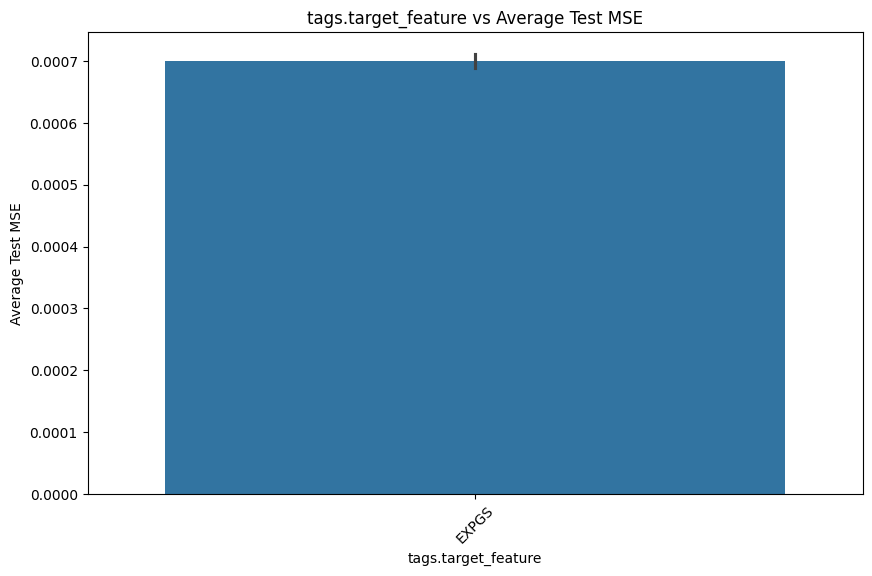

In [17]:
# Define a function to plot the average MSE for categorical tags
def plot_tag_vs_mse(tag, df):
    plt.figure(figsize=(10, 6))
    sns.barplot(x=tag, y="metrics.test_mse", data=df)
    plt.title(f'{tag} vs Average Test MSE')
    plt.xlabel(tag)
    plt.ylabel('Average Test MSE')
    plt.xticks(rotation=45)
    plt.show()

# Plot average MSE for each target feature
plot_tag_vs_mse("tags.target_feature", runs_df)
